# Category-Level Forecasting: Prophet

Forecasting each complaint category **independently** rather than the citywide aggregate. 
This matters because EDA confirmed categories have materially different
seasonal shapes (HEAT/HOT WATER: winter-spiky; Noise: summer/weekend;
Illegal Parking: steady) that partially cancel each other out in
aggregate — a single aggregate model loses that signal.

Prophet chosen specifically because:
- Native multiple seasonality (weekly + yearly simultaneously via
  Fourier terms) — directly addresses SARIMA's documented limitation
- Built-in holiday regressors — NYC 311 volume is holiday-sensitive
- Robust to missing days and outliers without manual preprocessing

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path
from prophet import Prophet
from prophet.plot import plot_components_plotly
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

WAREHOUSE_PATH = Path.cwd().parents[1] / "pipeline" / "warehouse" / "nyc311.duckdb"
con = duckdb.connect(str(WAREHOUSE_PATH), read_only=True)

# Load at category level -- not aggregated citywide this time
df = con.execute("""
    SELECT request_date, complaint_type, SUM(request_count) as y
    FROM fct_daily_demand
    GROUP BY request_date, complaint_type
    ORDER BY request_date, complaint_type
""").fetchdf()

# Apply trailing partial day trim
cutoff_date = df['request_date'].max()
df = df[df['request_date'] < cutoff_date].copy()
df = df.rename(columns={'request_date': 'ds'})

categories = sorted(df['complaint_type'].unique())
print(f"Categories: {len(categories)}")
print(f"Date range: {df['ds'].min().date()} to {df['ds'].max().date()}")
print(categories)

Categories: 14
Date range: 2023-06-01 to 2026-06-17
['Air Quality', 'Blocked Driveway', 'Damaged Tree', 'HEAT/HOT WATER', 'Illegal Parking', 'Noise - Commercial', 'Noise - Residential', 'Noise - Street/Sidewalk', 'PAINT/PLASTER', 'PLUMBING', 'Sewer', 'Street Condition', 'Traffic Signal Condition', 'Water System']


## Train/test split + US holidays

Same 90-day chronological split as the SARIMA baseline — kept identical
so model metrics are directly comparable. US federal holidays added as
explicit regressors; and Prophet handles these as additive adjustments
rather than treating them as unexplained noise.

In [2]:
TEST_DAYS = 90

def split_category(cat_df):
    train = cat_df.iloc[:-TEST_DAYS].copy()
    test = cat_df.iloc[-TEST_DAYS:].copy()
    return train, test

# US holidays dataframe in Prophet's required format
import holidays as hols

us_holidays = hols.US(years=range(2023, 2027))
holiday_df = pd.DataFrame([
    {'ds': pd.Timestamp(date), 'holiday': name}
    for date, name in us_holidays.items()
])
holiday_df = holiday_df.sort_values('ds').reset_index(drop=True)

print(f"Holiday count: {len(holiday_df)}")
print(holiday_df.head(10))

Holiday count: 47
          ds                               holiday
0 2023-01-01                        New Year's Day
1 2023-01-02             New Year's Day (observed)
2 2023-01-16            Martin Luther King Jr. Day
3 2023-02-20                 Washington's Birthday
4 2023-05-29                          Memorial Day
5 2023-06-19  Juneteenth National Independence Day
6 2023-07-04                      Independence Day
7 2023-09-04                             Labor Day
8 2023-10-09                          Columbus Day
9 2023-11-10               Veterans Day (observed)


## Fit Prophet models — one per category

Each category gets its own independently fitted Prophet model with
weekly + yearly seasonality and US holiday regressors. Fitting
sequentially across all 14 categories, storing forecasts and metrics
for the comparison notebook.

In [3]:
results = {}  # stores {category: {'forecast': df, 'mae': float, 'rmse': float, 'mape': float}}

for cat in categories:
    cat_df = df[df['complaint_type'] == cat][['ds', 'y']].reset_index(drop=True)
    train, test = split_category(cat_df)

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=holiday_df,
        seasonality_mode='multiplicative',  # better for series where variance scales with level
        interval_width=0.95
    )
    m.fit(train)

    future = m.make_future_dataframe(periods=TEST_DAYS)
    forecast = m.predict(future)

    # Extract test-period forecast only
    test_forecast = forecast[forecast['ds'].isin(test['ds'])]['yhat'].values
    actuals = test['y'].values

    mae = mean_absolute_error(actuals, test_forecast)
    rmse = np.sqrt(mean_squared_error(actuals, test_forecast))
    mape = mean_absolute_percentage_error(actuals, test_forecast) * 100

    results[cat] = {
        'model': m,
        'forecast': forecast,
        'test': test,
        'mae': mae,
        'rmse': rmse,
        'mape': mape
    }
    print(f"{cat:<35} MAE={mae:7.1f}  RMSE={rmse:7.1f}  MAPE={mape:.1f}%")

print("\nDone.")

18:36:45 - cmdstanpy - INFO - Chain [1] start processing
18:36:46 - cmdstanpy - INFO - Chain [1] done processing
18:36:46 - cmdstanpy - INFO - Chain [1] start processing


Air Quality                         MAE=    7.5  RMSE=    8.9  MAPE=28.2%


18:36:46 - cmdstanpy - INFO - Chain [1] done processing
18:36:47 - cmdstanpy - INFO - Chain [1] start processing


Blocked Driveway                    MAE=   90.0  RMSE=   97.9  MAPE=18.1%


18:36:47 - cmdstanpy - INFO - Chain [1] done processing
18:36:47 - cmdstanpy - INFO - Chain [1] start processing


...

Street Condition                    MAE=  239.5  RMSE=  263.3  MAPE=62.9%


18:36:52 - cmdstanpy - INFO - Chain [1] start processing
18:36:53 - cmdstanpy - INFO - Chain [1] done processing


Traffic Signal Condition            MAE=   76.2  RMSE=   84.2  MAPE=70.1%


18:36:53 - cmdstanpy - INFO - Chain [1] start processing
18:36:53 - cmdstanpy - INFO - Chain [1] done processing


Water System                        MAE=   81.7  RMSE=  116.3  MAPE=32.3%

Done.


## Results

| Category | MAE | RMSE | MAPE |
|---|---|---|---|
| Air Quality | 7.5 | 8.9 | 28.2% |
| Blocked Driveway | 90.0 | 97.9 | 18.1% |
| Damaged Tree | 121.5 | 185.5 | 136.7% |
| HEAT/HOT WATER | 222.4 | 307.5 | 59.2% |
| Illegal Parking | 123.4 | 153.2 | 7.1% |
| Noise - Commercial | 43.8 | 63.6 | 20.4% |
| Noise - Residential | 241.1 | 305.1 | 21.7% |
| Noise - Street/Sidewalk | 244.1 | 333.3 | 39.9% |
| PAINT/PLASTER | 25.5 | 31.6 | 15.4% |
| PLUMBING | 47.6 | 55.9 | 24.1% |
| Sewer | 46.3 | 112.4 | 35.6% |
| Street Condition | 239.5 | 263.3 | 62.9% |
| Traffic Signal Condition | 76.2 | 84.2 | 70.1% |
| Water System | 81.7 | 116.3 | 32.3% |

**Key findings:**
- **Illegal Parking (7.1%)** is the standout — steady, high-volume,
  smooth weekly pattern. Prophet's ideal use case.
- **Damaged Tree (136.7%)** is the clear failure — event-driven
  (storms) rather than seasonally predictable. Prophet's smooth
  decomposition has no signal to capture here.
- **HEAT/HOT WATER (59.2%)**: even with yearly seasonality enabled,
  threshold-driven cold-snap spikes remain poorly captured. Confirms
  EDA finding that this category needs spike-aware modeling.
- **Air Quality (28.2%)** MAPE is inflated by low volume (MAE=7.5
  requests/day is negligible operationally) — MAPE is an unreliable
  metric for sparse, low-volume series.
- **Pattern**: Prophet performs well on smooth, high-volume, weekly-
  driven categories; struggles with event/threshold-driven spikes.
  This is the core motivation for LightGBM next — lag features and
  tree splits handle threshold behavior that Fourier decomposition
  cannot.

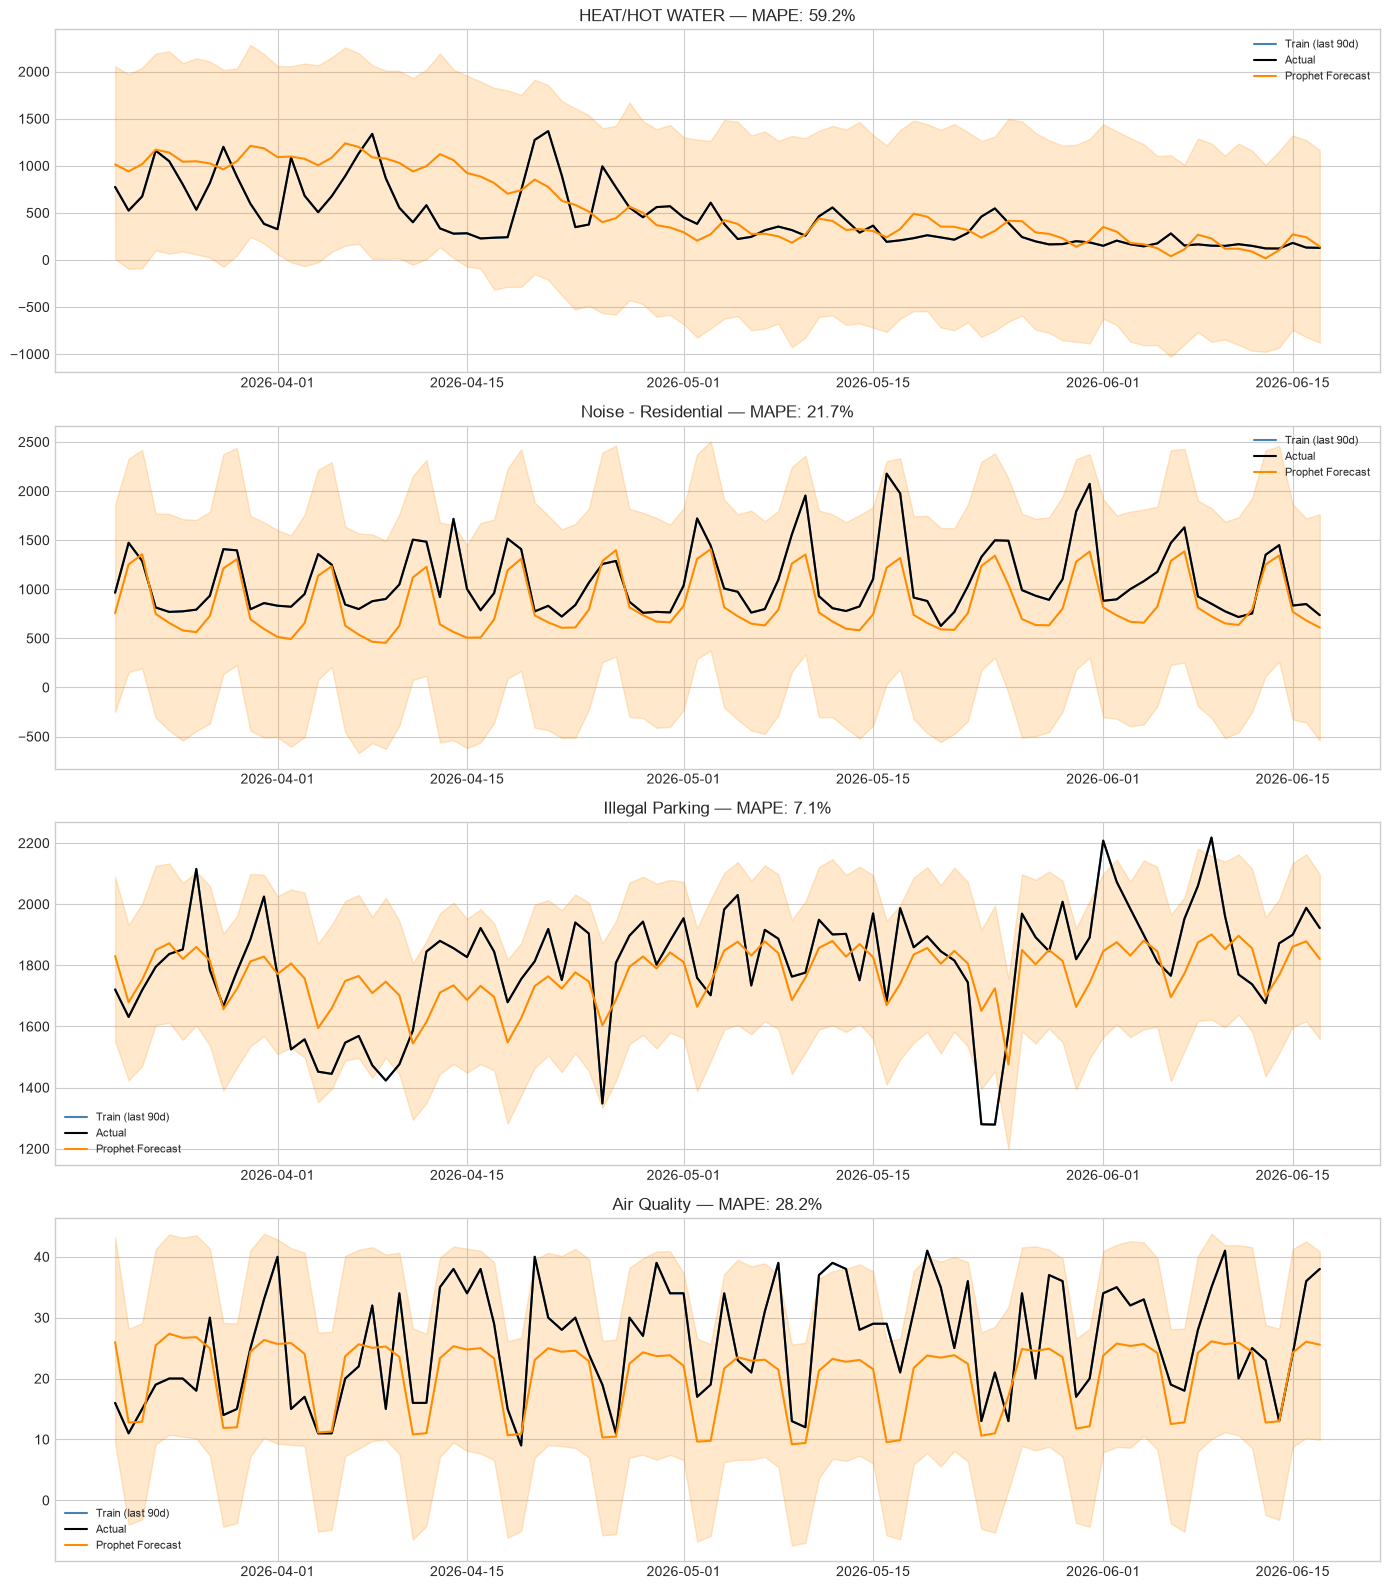

In [4]:
plot_categories = ['HEAT/HOT WATER', 'Noise - Residential', 'Illegal Parking', 'Air Quality']

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for ax, cat in zip(axes, plot_categories):
    r = results[cat]
    forecast = r['forecast']
    test = r['test']
    train_plot = df[df['complaint_type'] == cat][['ds', 'y']].iloc[-90:]

    ax.plot(train_plot['ds'], train_plot['y'], color='steelblue', label='Train (last 90d)')
    ax.plot(test['ds'], test['y'], color='black', label='Actual')
    ax.plot(forecast[forecast['ds'].isin(test['ds'])]['ds'],
            forecast[forecast['ds'].isin(test['ds'])]['yhat'],
            color='darkorange', label='Prophet Forecast')
    ax.fill_between(
        forecast[forecast['ds'].isin(test['ds'])]['ds'],
        forecast[forecast['ds'].isin(test['ds'])]['yhat_lower'],
        forecast[forecast['ds'].isin(test['ds'])]['yhat_upper'],
        alpha=0.2, color='darkorange'
    )
    ax.set_title(f'{cat} — MAPE: {r["mape"]:.1f}%')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Visual inspection:**

- **Illegal Parking**: tightest fit visually — forecast tracks actuals
  closely, narrow CI, misses limited to genuine outlier days.
- **Noise - Residential**: weekly shape correct but forecast runs
  below actuals — systematic underestimation as spring noise volume
  climbs faster than the yearly seasonality term expects.
- **HEAT/HOT WATER**: seasonal decline captured correctly but CI
  extends into negative values (impossible for a count series) —
  known Prophet limitation when multiplicative seasonality is applied
  to near-zero series.
- **Air Quality**: MAPE (28.2%) is misleading here. MAE of 7.5
  requests/day is negligible operationally — MAPE inflates on
  low-volume series and should not be the primary metric for this
  category.

## Summary

Prophet outperforms SARIMA on most categories, with meaningful
variation by category type:

- Works well for smooth, high-volume, weekly-driven categories
  (Illegal Parking: 7.1%, PAINT/PLASTER: 15.4%).
- Struggles with event/threshold-driven categories (Damaged Tree:
  136.7%, HEAT/HOT WATER: 59.2%) where Fourier seasonality has
  limited signal to work with.
- MAPE is unreliable for low-volume categories (Air Quality) --
  absolute error is the more honest metric there.

**Carrying forward**: LightGBM with lag features and calendar
variables is the next model tested. Tree-based splits handle
threshold and spike behavior directly, which is where Prophet
showed the most weakness.